# Wafer Map Defect Pattern Classification - CNN Baseline & Misclassification Analysis

- 기존 전처리 결과(`data/processed/*.npy`)를 불러와서 CNN baseline 모델을 다시 학습
- 테스트 평가, confusion matrix, normalized confusion matrix, 오분류 Top 20, 오분류 샘플 시각화까지 한 번에 정리

## 1. Google Drive 마운트

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. 기본 import 및 경로 설정

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = "/content/drive/MyDrive/wafer-map-defect-xai"

DATA_DIR = os.path.join(BASE_DIR, "data")
RAW_DIR = os.path.join(DATA_DIR, "raw")
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")

OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
FIGURE_PATH = os.path.join(OUTPUT_DIR, "figures")
MODEL_PATH = os.path.join(OUTPUT_DIR, "models")
REPORT_PATH = os.path.join(OUTPUT_DIR, "reports")

os.makedirs(FIGURE_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(REPORT_PATH, exist_ok=True)

print("BASE_DIR exists:", os.path.exists(BASE_DIR))
print("PROCESSED_DIR exists:", os.path.exists(PROCESSED_DIR))
print("MODEL_PATH:", MODEL_PATH)
print("FIGURE_PATH:", FIGURE_PATH)
print("REPORT_PATH:", REPORT_PATH)

if os.path.exists(PROCESSED_DIR):
    print("processed files:", os.listdir(PROCESSED_DIR))

BASE_DIR exists: True
PROCESSED_DIR exists: True
MODEL_PATH: /content/drive/MyDrive/wafer-map-defect-xai/outputs/models
FIGURE_PATH: /content/drive/MyDrive/wafer-map-defect-xai/outputs/figures
REPORT_PATH: /content/drive/MyDrive/wafer-map-defect-xai/outputs/reports
processed files: ['X_train.npy', 'X_val.npy', 'X_test.npy', 'y_val.npy', 'y_test.npy', 'y_train.npy', 'classes.npy']


## 3. 전처리된 데이터 로드

In [3]:
X_train = np.load(os.path.join(PROCESSED_DIR, "X_train.npy"))
X_val = np.load(os.path.join(PROCESSED_DIR, "X_val.npy"))
X_test = np.load(os.path.join(PROCESSED_DIR, "X_test.npy"))

y_train = np.load(os.path.join(PROCESSED_DIR, "y_train.npy"))
y_val = np.load(os.path.join(PROCESSED_DIR, "y_val.npy"))
y_test = np.load(os.path.join(PROCESSED_DIR, "y_test.npy"))

classes = np.load(os.path.join(PROCESSED_DIR, "classes.npy"), allow_pickle=True)

print("X_train:", X_train.shape, X_train.dtype)
print("X_val:", X_val.shape, X_val.dtype)
print("X_test:", X_test.shape, X_test.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("y_val:", y_val.shape, y_val.dtype)
print("y_test:", y_test.shape, y_test.dtype)
print("classes:", classes)

X_train: (121065, 64, 64, 1) uint8
X_val: (25942, 64, 64, 1) uint8
X_test: (25943, 64, 64, 1) uint8
y_train: (121065,) int64
y_val: (25942,) int64
y_test: (25943,) int64
classes: ['Center' 'Donut' 'Edge-Loc' 'Edge-Ring' 'Loc' 'Near-full' 'Random'
 'Scratch' 'none']


## 4. 데이터 정상 여부 확인

In [4]:
assert len(X_train) == len(y_train), "X_train과 y_train 개수가 다릅니다."
assert len(X_val) == len(y_val), "X_val과 y_val 개수가 다릅니다."
assert len(X_test) == len(y_test), "X_test와 y_test 개수가 다릅니다."

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))
print("Input shape:", X_train.shape[1:])
print("Number of classes:", len(classes))

Train: 121065
Validation: 25942
Test: 25943
Input shape: (64, 64, 1)
Number of classes: 9


## 5. 이미지 정규화

In [5]:
# 원본 값이 0, 1, 2로 구성되어 있으므로 2.0으로 나누어 0~1 범위로 정규화합니다.
X_train = X_train.astype("float32") / 2.0
X_val = X_val.astype("float32") / 2.0
X_test = X_test.astype("float32") / 2.0

print("X_train dtype:", X_train.dtype)
print("X_train min/max:", X_train.min(), X_train.max())
print("X_val min/max:", X_val.min(), X_val.max())
print("X_test min/max:", X_test.min(), X_test.max())

X_train dtype: float32
X_train min/max: 0.0 1.0
X_val min/max: 0.0 1.0
X_test min/max: 0.0 1.0


## 6. 클래스 분포 확인

In [6]:
train_dist = pd.Series(y_train).value_counts().sort_index()
val_dist = pd.Series(y_val).value_counts().sort_index()
test_dist = pd.Series(y_test).value_counts().sort_index()

dist_df = pd.DataFrame({
    "class": classes,
    "train": train_dist.values,
    "val": val_dist.values,
    "test": test_dist.values
})

dist_df

,class,train,val,test
0,Center,3006,644,644
1,Donut,389,83,83
2,Edge-Loc,3632,778,779
3,Edge-Ring,6776,1452,1452
4,Loc,2515,539,539
5,Near-full,104,23,22
6,Random,606,130,130
7,Scratch,835,179,179
8,none,103202,22114,22115


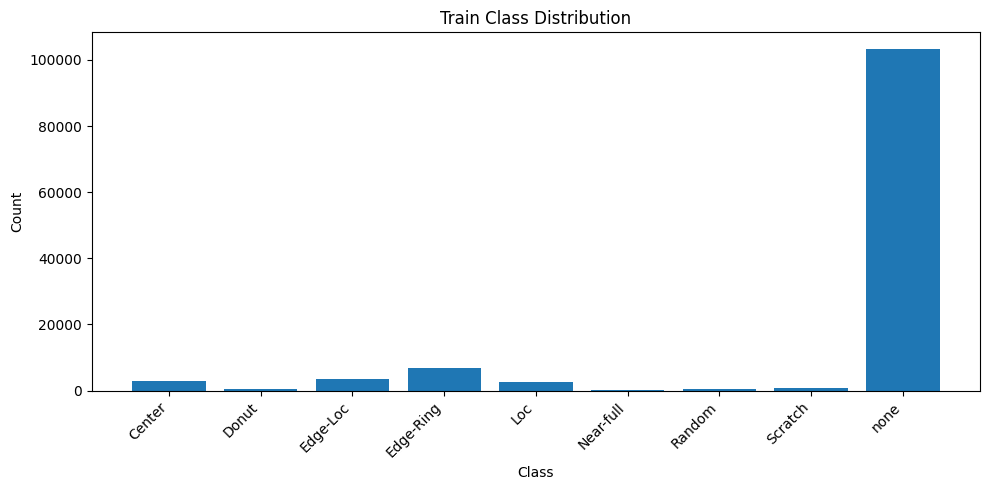

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/figures/train_class_distribution.png


In [7]:
plt.figure(figsize=(10, 5))
plt.bar(dist_df["class"], dist_df["train"])
plt.title("Train Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

save_path = os.path.join(FIGURE_PATH, "train_class_distribution.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

## 7. Class Weight 계산

In [8]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

for idx, weight in class_weight_dict.items():
    print(f"{idx} ({classes[idx]}): {weight:.4f}")

0 (Center): 4.4749
1 (Donut): 34.5801
2 (Edge-Loc): 3.7037
3 (Edge-Ring): 1.9852
4 (Loc): 5.3486
5 (Near-full): 129.3429
6 (Random): 22.1975
7 (Scratch): 16.1098
8 (none): 0.1303


## 8. TensorFlow 설정

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

NUM_CLASSES = len(classes)
INPUT_SHAPE = X_train.shape[1:]

print("NUM_CLASSES:", NUM_CLASSES)
print("INPUT_SHAPE:", INPUT_SHAPE)

TensorFlow version: 2.20.0
NUM_CLASSES: 9
INPUT_SHAPE: (64, 64, 1)


## 9. CNN Baseline 모델 정의

In [10]:
def build_cnn_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])

    return model

model = build_cnn_model(INPUT_SHAPE, NUM_CLASSES)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,440,905 (5.50 MB)

 Trainable params: 1,439,945 (5.49 MB)

 Non-trainable params: 960 (3.75 KB)

## 10. Callback 설정

In [11]:
checkpoint_path = os.path.join(MODEL_PATH, "best_cnn_model.keras")

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("Best model will be saved to:", checkpoint_path)

Best model will be saved to: /content/drive/MyDrive/wafer-map-defect-xai/outputs/models/best_cnn_model.keras


## 11. 모델 학습

In [12]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=128,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/30
946/946 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2761 - loss: 2.4524
Epoch 1: val_loss improved from None to 1.20867, saving model to /content/drive/MyDrive/wafer-map-defect-xai/outputs/models/best_cnn_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/wafer-map-defect-xai/outputs/models/best_cnn_model.keras
946/946 ━━━━━━━━━━━━━━━━━━━━ 44s 36ms/step - accuracy: 0.2760 - loss: 1.9212 - val_accuracy: 0.7583 - val_loss: 1.2087 - learning_rate: 0.0010
Epoch 2/30
945/946 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3459 - loss: 1.5830
Epoch 2: val_loss did not improve from 1.20867
946/946 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - accuracy: 0.3167 - loss: 1.5332 - val_accuracy: 0.3981 - val_loss: 1.2827 - learning_rate: 0.0010
Epoch 3/30
945/946 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4013 - loss: 1.3808
Epoch 3: val_loss improved from 1.20867 to 1.19118, saving model to /content/drive/MyDrive/wafer-map-defect-xai/outputs/models/best_cnn_model.kera

## 12. 학습 곡선 시각화

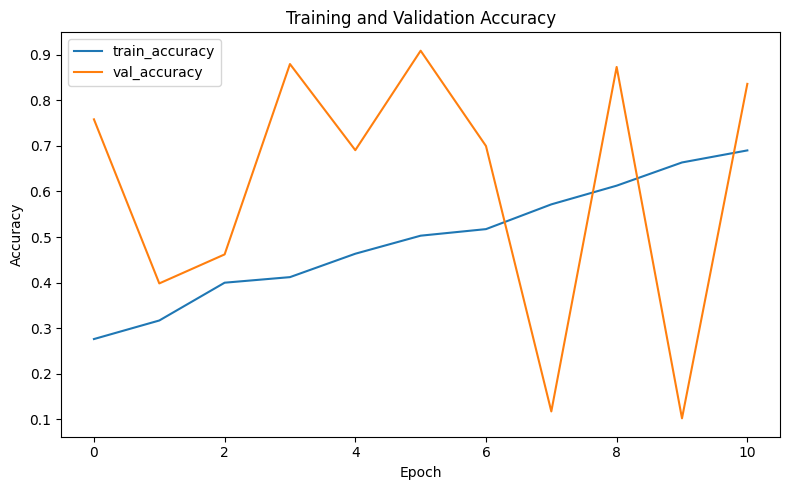

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/figures/cnn_accuracy_curve.png


In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()

save_path = os.path.join(FIGURE_PATH, "cnn_accuracy_curve.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

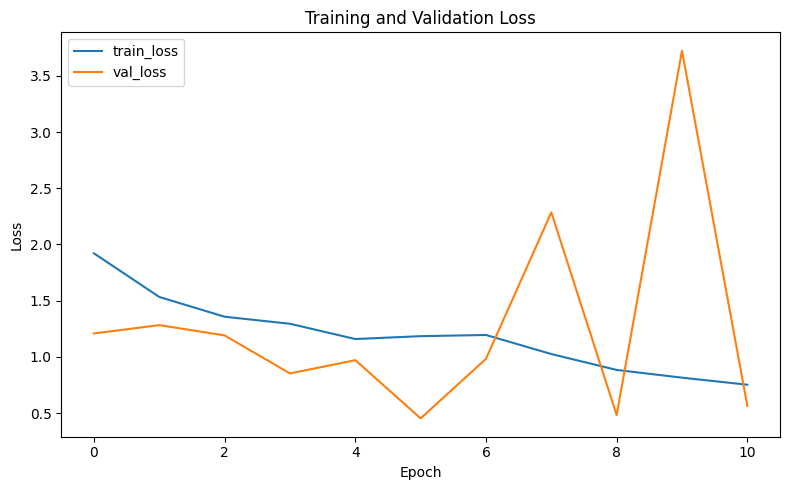

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/figures/cnn_loss_curve.png


In [14]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

save_path = os.path.join(FIGURE_PATH, "cnn_loss_curve.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

## 13. Test Set 평가

In [15]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

811/811 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9090 - loss: 0.4689
Test Loss: 0.46893954277038574
Test Accuracy: 0.9089927673339844


## 14. 예측값 생성 및 Classification Report

In [16]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("y_pred_prob shape:", y_pred_prob.shape)
print("y_pred shape:", y_pred.shape)

report_text = classification_report(y_test, y_pred, target_names=classes)
print(report_text)

report_path = os.path.join(REPORT_PATH, "cnn_baseline_classification_report.txt")
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print("Saved:", report_path)

811/811 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
y_pred_prob shape: (25943, 9)
y_pred shape: (25943,)
              precision    recall  f1-score   support

      Center       0.60      0.90      0.72       644
       Donut       0.33      0.23      0.27        83
    Edge-Loc       0.34      0.24      0.28       779
   Edge-Ring       0.99      0.84      0.91      1452
         Loc       0.13      0.06      0.08       539
   Near-full       1.00      0.09      0.17        22
      Random       0.49      0.81      0.61       130
     Scratch       0.03      0.02      0.02       179
        none       0.95      0.97      0.96     22115

    accuracy                           0.91     25943
   macro avg       0.54      0.46      0.45     25943
weighted avg       0.90      0.91      0.90     25943

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/reports/cnn_baseline_classification_report.txt


## 15. Confusion Matrix

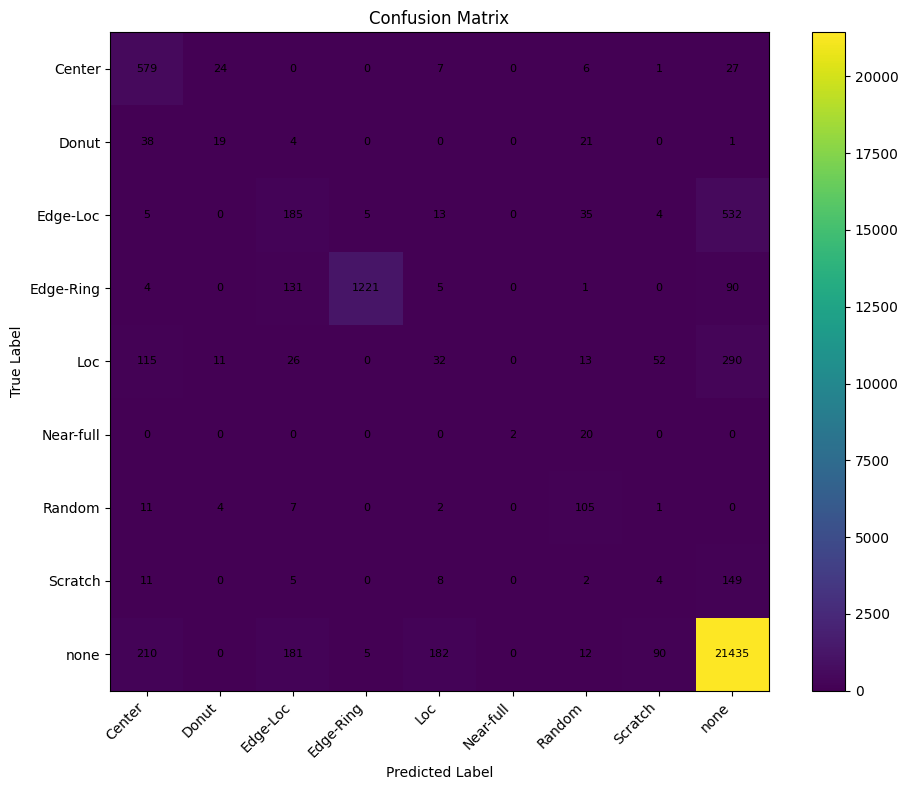

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/figures/confusion_matrix.png


In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(classes)), classes, rotation=45, ha="right")
plt.yticks(np.arange(len(classes)), classes)
plt.colorbar()

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)

plt.tight_layout()

save_path = os.path.join(FIGURE_PATH, "confusion_matrix.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

## 16. Normalized Confusion Matrix

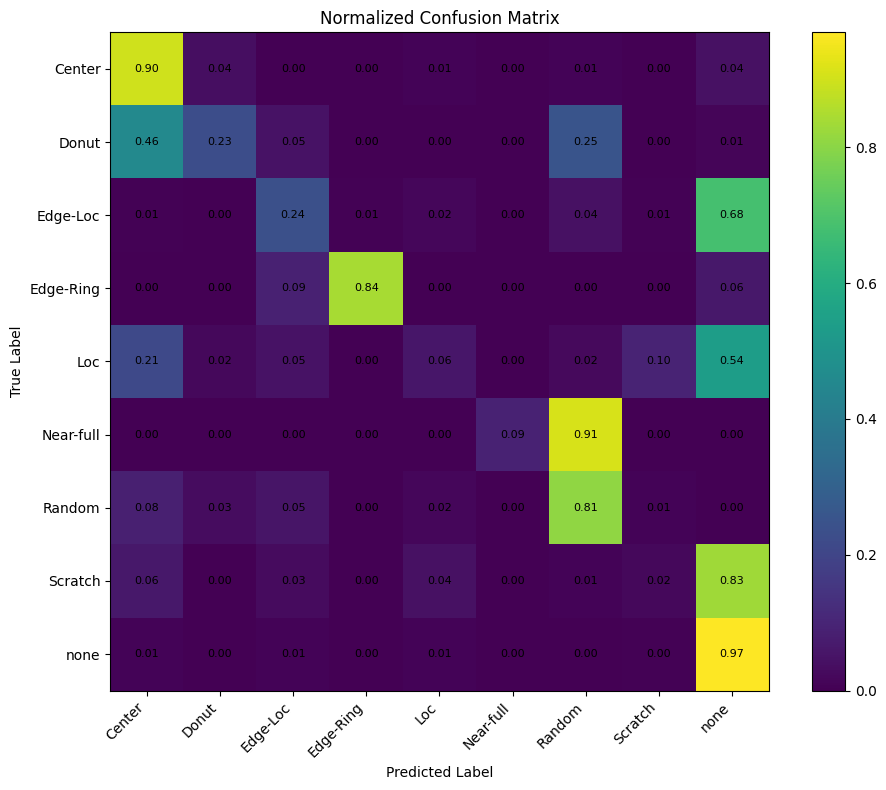

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/figures/normalized_confusion_matrix.png


In [18]:
# true class 기준 정규화
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
plt.imshow(cm_norm)
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(classes)), classes, rotation=45, ha="right")
plt.yticks(np.arange(len(classes)), classes)
plt.colorbar()

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(
            j, i,
            f"{cm_norm[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()

save_path = os.path.join(FIGURE_PATH, "normalized_confusion_matrix.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

## 17. 오분류 Top 20 분석

In [19]:
error_df = pd.DataFrame({
    "true": y_test,
    "pred": y_pred
})

error_df = error_df[error_df["true"] != error_df["pred"]].copy()

error_df["true_label"] = error_df["true"].apply(lambda x: classes[x])
error_df["pred_label"] = error_df["pred"].apply(lambda x: classes[x])

top_errors = (
    error_df
    .groupby(["true_label", "pred_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

top20_errors = top_errors.head(20)
top20_errors

,true_label,pred_label,count
14,Edge-Loc,none,532
25,Loc,none,290
37,none,Center,210
40,none,Loc,182
38,none,Edge-Loc,181
36,Scratch,none,149
16,Edge-Ring,Edge-Loc,131
20,Loc,Center,115
19,Edge-Ring,none,90
42,none,Scratch,90


In [20]:
top_error_path = os.path.join(REPORT_PATH, "misclassification_top20.csv")
top20_errors.to_csv(top_error_path, index=False, encoding="utf-8-sig")

print("Saved:", top_error_path)

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/reports/misclassification_top20.csv


## 18. 오분류 샘플 시각화 함수

In [21]:
def show_misclassified_samples(true_label_name, pred_label_name=None, n=12, save=False):
    true_idx = list(classes).index(true_label_name)

    if pred_label_name is None:
        indices = np.where((y_test == true_idx) & (y_pred != true_idx))[0]
        title = f"True {true_label_name} / Pred Wrong"
        file_name = f"misclassified_true_{true_label_name}.png"
    else:
        pred_idx = list(classes).index(pred_label_name)
        indices = np.where((y_test == true_idx) & (y_pred == pred_idx))[0]
        title = f"True {true_label_name} / Pred {pred_label_name}"
        file_name = f"misclassified_true_{true_label_name}_pred_{pred_label_name}.png"

    if len(indices) == 0:
        print("No samples found.")
        return

    selected = indices[:n]

    cols = 4
    rows = int(np.ceil(len(selected) / cols))

    plt.figure(figsize=(cols * 3, rows * 3))

    for i, idx in enumerate(selected):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(X_test[idx].squeeze(), cmap="gray")
        plt.axis("off")
        plt.title(
            f"T: {classes[y_test[idx]]}\nP: {classes[y_pred[idx]]}",
            fontsize=9
        )

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()

    if save:
        save_path = os.path.join(FIGURE_PATH, file_name)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()

## 19. 주요 클래스 오분류 샘플 확인

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/figures/misclassified_true_Scratch.png


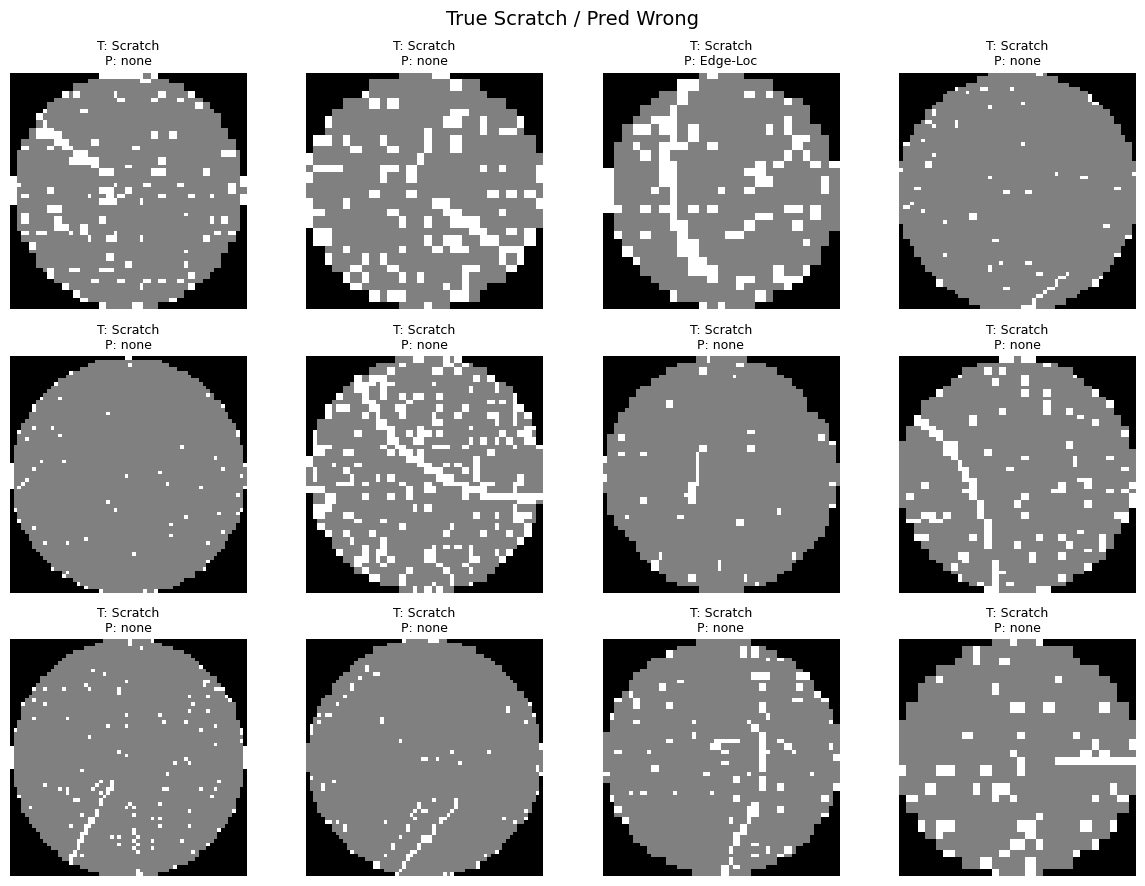

In [22]:
show_misclassified_samples("Scratch", n=12, save=True)

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/figures/misclassified_true_Loc.png


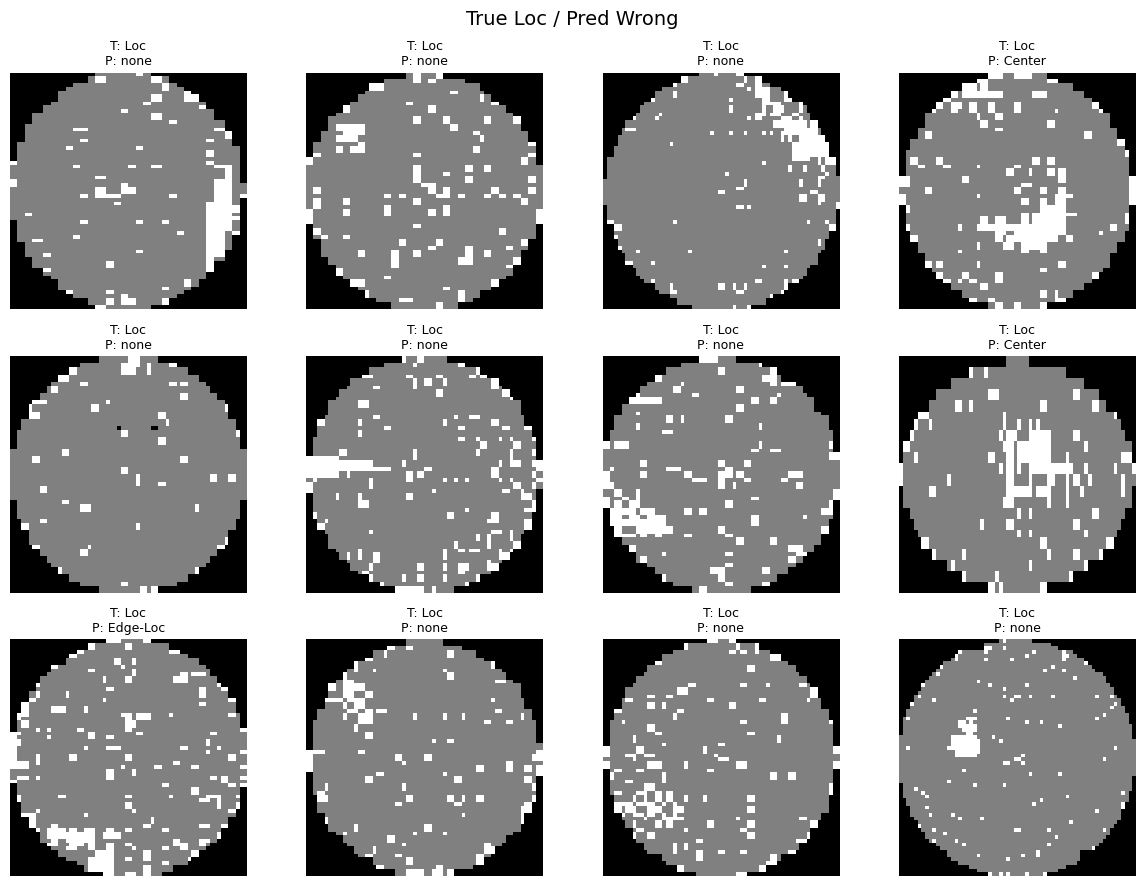

In [23]:
show_misclassified_samples("Loc", n=12, save=True)

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/figures/misclassified_true_Edge-Loc.png


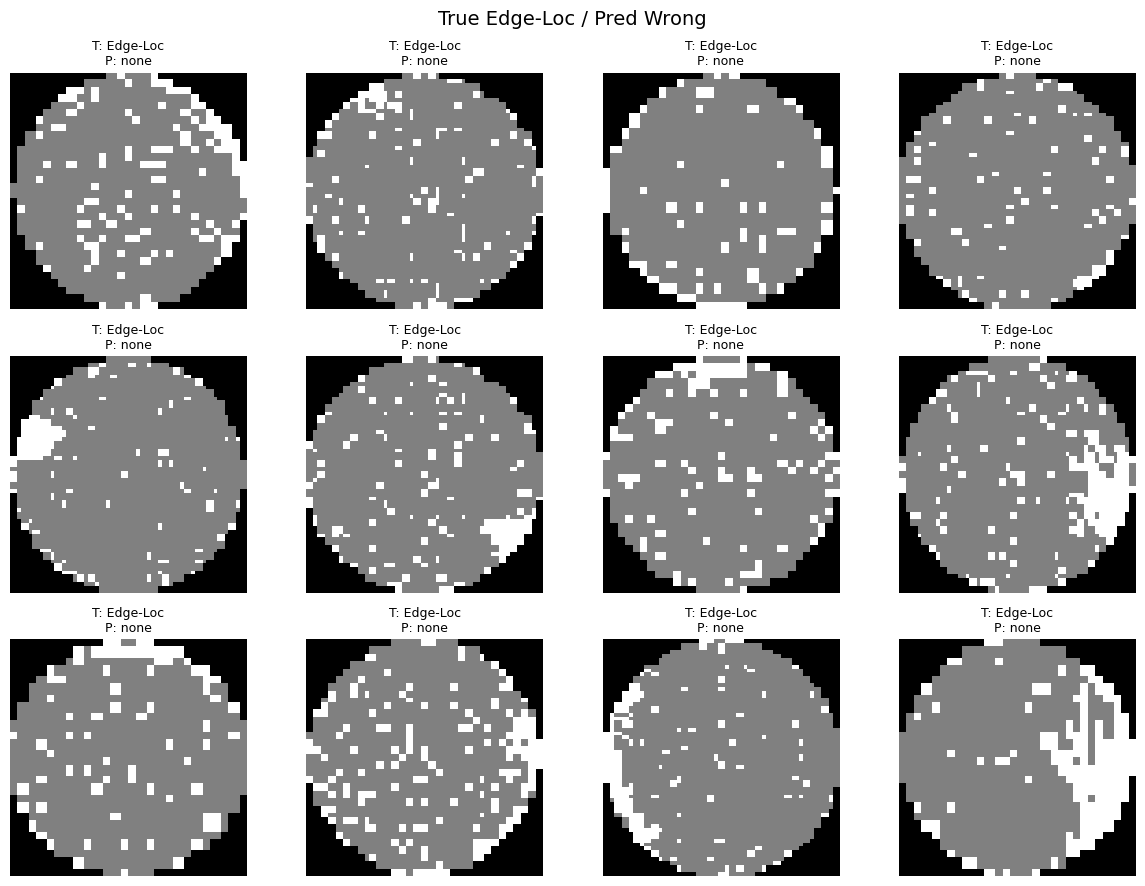

In [24]:
show_misclassified_samples("Edge-Loc", n=12, save=True)

## 20. 특정 오분류 조합 확인

In [25]:
# Top 20 결과를 보고 필요한 조합만 실행하세요.
# 예시:
# show_misclassified_samples("Loc", "Edge-Loc", n=12, save=True)
# show_misclassified_samples("Edge-Loc", "Loc", n=12, save=True)
# show_misclassified_samples("none", "Scratch", n=12, save=True)
# show_misclassified_samples("Scratch", "none", n=12, save=True)

## 21. 결과 요약 Markdown 자동 생성

In [26]:
summary_md = f"""# CNN Baseline Result

## 1. 실험 개요

본 실험은 WM-811K / LSWMD 웨이퍼 맵 데이터셋을 대상으로 CNN baseline 모델을 학습하고, 클래스별 성능과 오분류 패턴을 분석하기 위해 수행하였다.

## 2. 데이터 분할

- Train: {len(X_train):,}
- Validation: {len(X_val):,}
- Test: {len(X_test):,}
- Input shape: {INPUT_SHAPE}
- Classes: {', '.join(map(str, classes))}

## 3. 학습 설정

- Model: CNN Baseline
- Optimizer: Adam
- Loss: Sparse Categorical Crossentropy
- Batch size: 128
- Class weight: Applied
- Early stopping: Applied
- Model checkpoint: Applied

## 4. Test 결과

- Test Loss: {test_loss:.4f}
- Test Accuracy: {test_acc:.4f}

## 5. 해석 시 주의점

전체 accuracy가 높게 나타나더라도, 본 데이터셋은 `none` 클래스가 매우 많은 불균형 구조를 가진다. 따라서 accuracy만으로 모델 성능을 판단하기보다, macro F1-score와 클래스별 precision, recall, f1-score를 함께 확인해야 한다.

## 6. 오분류 분석

Normalized Confusion Matrix와 오분류 Top 20 표를 통해 모델이 어떤 클래스를 주로 혼동하는지 확인하였다. 특히 Scratch, Loc, Edge-Loc 클래스는 시각적 패턴이 애매하거나 데이터 수가 상대적으로 적어 오분류 가능성이 높다.

Scratch 클래스는 실제 Scratch 샘플을 일부 탐지할 수 있지만, Scratch가 아닌 샘플까지 Scratch로 예측하는 false positive 문제가 발생할 수 있다. Loc와 Edge-Loc는 결함이 특정 위치에 집중된다는 점에서 유사하므로 서로 혼동될 가능성이 있다.

## 7. 저장된 산출물

- `outputs/models/best_cnn_model.keras`
- `outputs/figures/confusion_matrix.png`
- `outputs/figures/normalized_confusion_matrix.png`
- `outputs/reports/cnn_baseline_classification_report.txt`
- `outputs/reports/misclassification_top20.csv`
"""

summary_path = os.path.join(REPORT_PATH, "cnn_baseline_result.md")

with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_md)

print("Saved:", summary_path)

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/reports/cnn_baseline_result.md


In [27]:
# ============================================================
# Experiment A: CNN without class_weight
# ============================================================

EXPERIMENT_NAME = "cnn_without_class_weight"

MODEL_SAVE_PATH_NO_CW = os.path.join(
    MODEL_PATH,
    "best_cnn_without_class_weight.keras"
)

REPORT_SAVE_PATH_NO_CW = os.path.join(
    REPORT_PATH,
    "classification_report_without_class_weight.txt"
)

CM_SAVE_PATH_NO_CW = os.path.join(
    FIGURE_PATH,
    "confusion_matrix_without_class_weight.png"
)

NORM_CM_SAVE_PATH_NO_CW = os.path.join(
    FIGURE_PATH,
    "normalized_confusion_matrix_without_class_weight.png"
)

TOP_ERROR_SAVE_PATH_NO_CW = os.path.join(
    REPORT_PATH,
    "misclassification_top20_without_class_weight.csv"
)

print("Experiment:", EXPERIMENT_NAME)
print("Model save path:", MODEL_SAVE_PATH_NO_CW)

Experiment: cnn_without_class_weight
Model save path: /content/drive/MyDrive/wafer-map-defect-xai/outputs/models/best_cnn_without_class_weight.keras


# class_weight 없는 새 모델 만들기

In [28]:
from tensorflow.keras import layers, models

model_no_cw = models.Sequential([
    layers.Input(shape=INPUT_SHAPE),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model_no_cw.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_no_cw.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,440,905 (5.50 MB)

 Trainable params: 1,439,945 (5.49 MB)

 Non-trainable params: 960 (3.75 KB)

# 콜백 설정

In [29]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks_no_cw = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=MODEL_SAVE_PATH_NO_CW,
        monitor="val_loss",
        save_best_only=True
    )
]

print("Callbacks ready.")

Callbacks ready.


# class_weight 없이 학습

In [30]:
history_no_cw = model_no_cw.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=128,
    callbacks=callbacks_no_cw
)

Epoch 1/30
946/946 ━━━━━━━━━━━━━━━━━━━━ 39s 33ms/step - accuracy: 0.9279 - loss: 0.2953 - val_accuracy: 0.9280 - val_loss: 0.3634
Epoch 2/30
946/946 ━━━━━━━━━━━━━━━━━━━━ 24s 26ms/step - accuracy: 0.9503 - loss: 0.1708 - val_accuracy: 0.9536 - val_loss: 0.1492
Epoch 3/30
946/946 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.9556 - loss: 0.1441 - val_accuracy: 0.9549 - val_loss: 0.1647
Epoch 4/30
946/946 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.9586 - loss: 0.1302 - val_accuracy: 0.9622 - val_loss: 0.1245
Epoch 5/30
946/946 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.9624 - loss: 0.1173 - val_accuracy: 0.9661 - val_loss: 0.1107
Epoch 6/30
946/946 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.9657 - loss: 0.1042 - val_accuracy: 0.9632 - val_loss: 0.1346
Epoch 7/30
946/946 ━━━━━━━━━━━━━━━━━━━━ 42s 26ms/step - accuracy: 0.9685 - loss: 0.0945 - val_accuracy: 0.9686 - val_loss: 0.1139
Epoch 8/30
946/946 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.9719 - loss: 0.0830 - 

# 테스트 평가

In [31]:
test_loss_no_cw, test_acc_no_cw = model_no_cw.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss without class_weight: {test_loss_no_cw:.4f}")
print(f"Test Accuracy without class_weight: {test_acc_no_cw:.4f}")

Test Loss without class_weight: 0.1145
Test Accuracy without class_weight: 0.9654


# 예측값 생성

In [32]:
import numpy as np

y_pred_prob_no_cw = model_no_cw.predict(X_test)
y_pred_no_cw = np.argmax(y_pred_prob_no_cw, axis=1)

print("y_pred_prob_no_cw shape:", y_pred_prob_no_cw.shape)
print("y_pred_no_cw shape:", y_pred_no_cw.shape)

811/811 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
y_pred_prob_no_cw shape: (25943, 9)
y_pred_no_cw shape: (25943,)


# classification report 생성

In [33]:
from sklearn.metrics import classification_report

report_no_cw = classification_report(
    y_test,
    y_pred_no_cw,
    target_names=classes,
    digits=4
)

print(report_no_cw)

with open(REPORT_SAVE_PATH_NO_CW, "w", encoding="utf-8") as f:
    f.write(report_no_cw)

print("Saved:", REPORT_SAVE_PATH_NO_CW)

              precision    recall  f1-score   support

      Center     0.9109    0.9363    0.9234       644
       Donut     0.8197    0.6024    0.6944        83
    Edge-Loc     0.7021    0.8318    0.7615       779
   Edge-Ring     0.9836    0.9490    0.9660      1452
         Loc     0.6733    0.6883    0.6807       539
   Near-full     0.6538    0.7727    0.7083        22
      Random     0.9479    0.7000    0.8053       130
     Scratch     0.7778    0.0391    0.0745       179
        none     0.9850    0.9894    0.9872     22115

    accuracy                         0.9654     25943
   macro avg     0.8282    0.7232    0.7335     25943
weighted avg     0.9657    0.9654    0.9629     25943

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/reports/classification_report_without_class_weight.txt


# confusion matrix 생성


In [34]:
from sklearn.metrics import confusion_matrix

cm_no_cw = confusion_matrix(y_test, y_pred_no_cw)

print(cm_no_cw)

[[  603     4     1     0     4     0     0     0    32]
 [    4    50     8     0    14     0     0     0     7]
 [    3     0   648     6    26     3     1     0    92]
 [    2     0    55  1378     0     0     0     0    17]
 [   16     2    47     1   371     0     1     2    99]
 [    0     0     5     0     0    17     0     0     0]
 [    5     3    15     1     2     6    91     0     7]
 [    1     1     9     1    79     0     2     7    79]
 [   28     1   135    14    55     0     1     0 21881]]


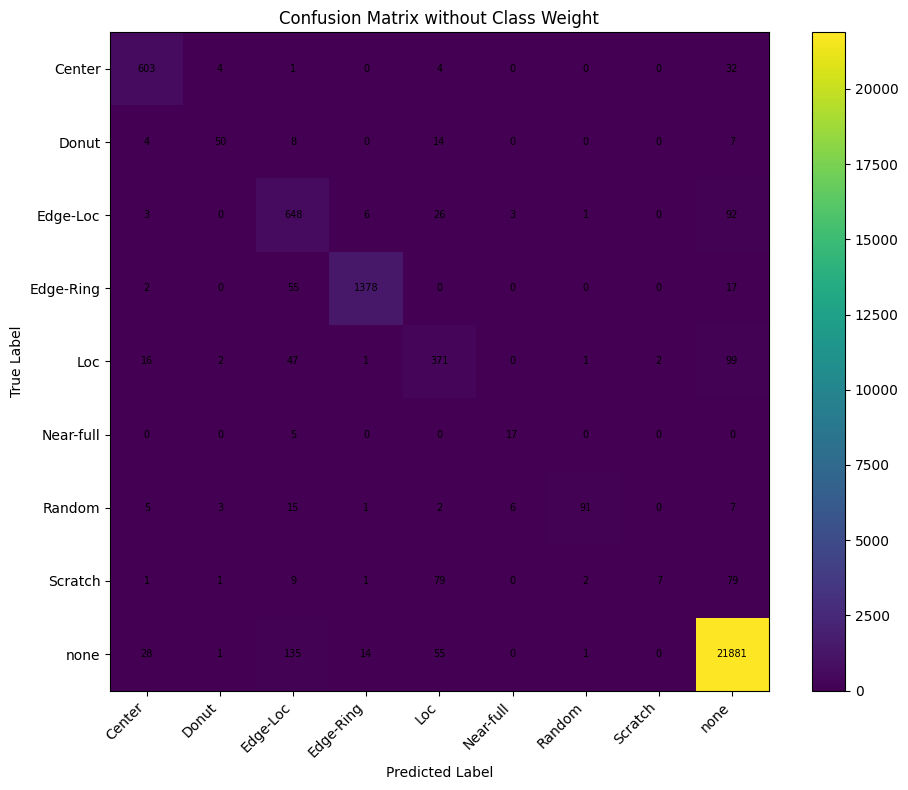

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/figures/confusion_matrix_without_class_weight.png


In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(cm_no_cw)
plt.title("Confusion Matrix without Class Weight")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(classes)), classes, rotation=45, ha="right")
plt.yticks(np.arange(len(classes)), classes)
plt.colorbar()

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(
            j, i,
            str(cm_no_cw[i, j]),
            ha="center",
            va="center",
            fontsize=7
        )

plt.tight_layout()
plt.savefig(CM_SAVE_PATH_NO_CW, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", CM_SAVE_PATH_NO_CW)

# normalized confusion matrix 저장

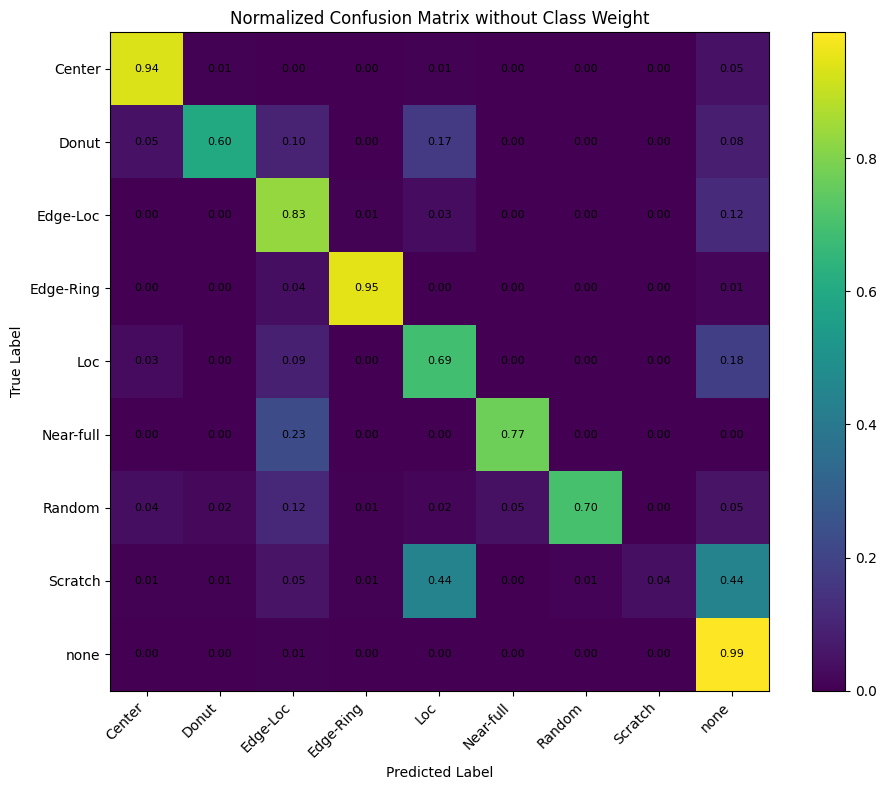

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/figures/normalized_confusion_matrix_without_class_weight.png


In [36]:
cm_norm_no_cw = cm_no_cw.astype("float") / cm_no_cw.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
plt.imshow(cm_norm_no_cw)
plt.title("Normalized Confusion Matrix without Class Weight")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(classes)), classes, rotation=45, ha="right")
plt.yticks(np.arange(len(classes)), classes)
plt.colorbar()

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(
            j, i,
            f"{cm_norm_no_cw[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.savefig(NORM_CM_SAVE_PATH_NO_CW, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", NORM_CM_SAVE_PATH_NO_CW)

# 오분류 Top 20 생성

In [37]:
import pandas as pd

error_df_no_cw = pd.DataFrame({
    "true": y_test,
    "pred": y_pred_no_cw
})

error_df_no_cw = error_df_no_cw[
    error_df_no_cw["true"] != error_df_no_cw["pred"]
].copy()

error_df_no_cw["true_label"] = error_df_no_cw["true"].apply(lambda x: classes[x])
error_df_no_cw["pred_label"] = error_df_no_cw["pred"].apply(lambda x: classes[x])

top_errors_no_cw = (
    error_df_no_cw
    .groupby(["true_label", "pred_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(top_errors_no_cw.head(20))

top_errors_no_cw.head(20).to_csv(
    TOP_ERROR_SAVE_PATH_NO_CW,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", TOP_ERROR_SAVE_PATH_NO_CW)

,true_label,pred_label,count
41,none,Edge-Loc,135
23,Loc,none,99
13,Edge-Loc,none,92
36,Scratch,Loc,79
38,Scratch,none,79
43,none,Loc,55
15,Edge-Ring,Edge-Loc,55
19,Loc,Edge-Loc,47
3,Center,none,32
39,none,Center,28


Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/reports/misclassification_top20_without_class_weight.csv


# 기존 class_weight 모델과 비교표 만들기

In [38]:
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

# without class_weight 지표
acc_no_cw = accuracy_score(y_test, y_pred_no_cw)
macro_f1_no_cw = f1_score(y_test, y_pred_no_cw, average="macro")
weighted_f1_no_cw = f1_score(y_test, y_pred_no_cw, average="weighted")

precision_no_cw, recall_no_cw, f1_no_cw, support_no_cw = precision_recall_fscore_support(
    y_test,
    y_pred_no_cw,
    labels=np.arange(len(classes))
)

summary_no_cw = pd.DataFrame({
    "class": classes,
    "precision": precision_no_cw,
    "recall": recall_no_cw,
    "f1": f1_no_cw,
    "support": support_no_cw
})

display(summary_no_cw)

print("Accuracy without class_weight:", acc_no_cw)
print("Macro F1 without class_weight:", macro_f1_no_cw)
print("Weighted F1 without class_weight:", weighted_f1_no_cw)

,class,precision,recall,f1,support
0,Center,0.910876,0.936335,0.923430,644
1,Donut,0.819672,0.602410,0.694444,83
2,Edge-Loc,0.702059,0.831836,0.761457,779
3,Edge-Ring,0.983583,0.949036,0.966001,1452
4,Loc,0.673321,0.688312,0.680734,539
5,Near-full,0.653846,0.772727,0.708333,22
6,Random,0.947917,0.700000,0.805310,130
7,Scratch,0.777778,0.039106,0.074468,179
8,none,0.985009,0.989419,0.987209,22115


Accuracy without class_weight: 0.9654241992059515
Macro F1 without class_weight: 0.7334874389265044
Weighted F1 without class_weight: 0.962910544085872


In [39]:
import os

print(os.listdir(MODEL_PATH))

['best_cnn_model.keras', 'best_cnn_without_class_weight.keras']


In [40]:
print(os.listdir(REPORT_PATH))
print(os.listdir(FIGURE_PATH))

['cnn_baseline_classification_report.txt', 'misclassification_top20.csv', 'cnn_baseline_result.md', 'classification_report_without_class_weight.txt', 'misclassification_top20_without_class_weight.csv']
['train_class_distribution.png', 'cnn_accuracy_curve.png', 'cnn_loss_curve.png', 'confusion_matrix.png', 'normalized_confusion_matrix.png', 'misclassified_true_Scratch.png', 'misclassified_true_Loc.png', 'misclassified_true_Edge-Loc.png', 'confusion_matrix_without_class_weight.png', 'normalized_confusion_matrix_without_class_weight.png']


# Experiment B. CNN with none downsampling

In [41]:
# ============================================================
# Experiment B: CNN with none downsampling
# ============================================================

EXPERIMENT_NAME = "cnn_none_downsampling"

MODEL_SAVE_PATH_DS = os.path.join(
    MODEL_PATH,
    "best_cnn_none_downsampling.keras"
)

REPORT_SAVE_PATH_DS = os.path.join(
    REPORT_PATH,
    "classification_report_none_downsampling.txt"
)

CM_SAVE_PATH_DS = os.path.join(
    FIGURE_PATH,
    "confusion_matrix_none_downsampling.png"
)

NORM_CM_SAVE_PATH_DS = os.path.join(
    FIGURE_PATH,
    "normalized_confusion_matrix_none_downsampling.png"
)

TOP_ERROR_SAVE_PATH_DS = os.path.join(
    REPORT_PATH,
    "misclassification_top20_none_downsampling.csv"
)

print("Experiment:", EXPERIMENT_NAME)
print("Model save path:", MODEL_SAVE_PATH_DS)

Experiment: cnn_none_downsampling
Model save path: /content/drive/MyDrive/wafer-map-defect-xai/outputs/models/best_cnn_none_downsampling.keras


In [43]:
none_idx = np.where(classes == "none")[0][0]

print("none class index:", none_idx)
print("none class name:", classes[none_idx])

none class index: 8
none class name: none


In [44]:
import numpy as np

none_indices = np.where(y_train == none_idx)[0]
defect_indices = np.where(y_train != none_idx)[0]

print("Original train size:", len(y_train))
print("none count:", len(none_indices))
print("defect count:", len(defect_indices))

Original train size: 121065
none count: 103202
defect count: 17863


In [45]:
RANDOM_STATE = 42

# Option B: none 클래스 수를 defect 전체 수의 2배로 제한
target_none_count = min(len(none_indices), len(defect_indices) * 2)

print("Target none count:", target_none_count)

Target none count: 35726


In [46]:
rng = np.random.default_rng(RANDOM_STATE)

sampled_none_indices = rng.choice(
    none_indices,
    size=target_none_count,
    replace=False
)

downsampled_indices = np.concatenate([
    defect_indices,
    sampled_none_indices
])

rng.shuffle(downsampled_indices)

X_train_ds = X_train[downsampled_indices]
y_train_ds = y_train[downsampled_indices]

print("Downsampled train size:", len(y_train_ds))
print("X_train_ds shape:", X_train_ds.shape)
print("y_train_ds shape:", y_train_ds.shape)

Downsampled train size: 53589
X_train_ds shape: (53589, 64, 64, 1)
y_train_ds shape: (53589,)


In [47]:
import pandas as pd

ds_class_counts = pd.Series(y_train_ds).value_counts().sort_index()

ds_distribution = pd.DataFrame({
    "class": classes,
    "count": [ds_class_counts.get(i, 0) for i in range(len(classes))]
})

display(ds_distribution)

,class,count
0,Center,3006
1,Donut,389
2,Edge-Loc,3632
3,Edge-Ring,6776
4,Loc,2515
5,Near-full,104
6,Random,606
7,Scratch,835
8,none,35726


In [48]:
from tensorflow.keras import layers, models

model_ds = models.Sequential([
    layers.Input(shape=INPUT_SHAPE),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model_ds.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_ds.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,440,905 (5.50 MB)

 Trainable params: 1,439,945 (5.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [49]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks_ds = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=MODEL_SAVE_PATH_DS,
        monitor="val_loss",
        save_best_only=True
    )
]

print("Callbacks ready.")

Callbacks ready.


In [50]:
history_ds = model_ds.fit(
    X_train_ds,
    y_train_ds,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=128,
    callbacks=callbacks_ds
)

Epoch 1/30
419/419 ━━━━━━━━━━━━━━━━━━━━ 30s 54ms/step - accuracy: 0.8372 - loss: 0.6298 - val_accuracy: 0.1547 - val_loss: 1.5343
Epoch 2/30
419/419 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.8975 - loss: 0.3284 - val_accuracy: 0.9576 - val_loss: 0.1447
Epoch 3/30
419/419 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.9135 - loss: 0.2698 - val_accuracy: 0.9495 - val_loss: 0.1752
Epoch 4/30
419/419 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.9232 - loss: 0.2376 - val_accuracy: 0.9436 - val_loss: 0.3727
Epoch 5/30
419/419 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.9293 - loss: 0.2154 - val_accuracy: 0.9630 - val_loss: 0.1404
Epoch 6/30
419/419 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9376 - loss: 0.1858 - val_accuracy: 0.9587 - val_loss: 0.1422
Epoch 7/30
419/419 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9411 - loss: 0.1737 - val_accuracy: 0.9399 - val_loss: 0.5447
Epoch 8/30
419/419 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.9480 - loss: 0.1494 - 

In [51]:
test_loss_ds, test_acc_ds = model_ds.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss with none downsampling: {test_loss_ds:.4f}")
print(f"Test Accuracy with none downsampling: {test_acc_ds:.4f}")

Test Loss with none downsampling: 0.1338
Test Accuracy with none downsampling: 0.9632


In [52]:
y_pred_prob_ds = model_ds.predict(X_test)
y_pred_ds = np.argmax(y_pred_prob_ds, axis=1)

print("y_pred_prob_ds shape:", y_pred_prob_ds.shape)
print("y_pred_ds shape:", y_pred_ds.shape)

811/811 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
y_pred_prob_ds shape: (25943, 9)
y_pred_ds shape: (25943,)


In [53]:
from sklearn.metrics import classification_report

report_ds = classification_report(
    y_test,
    y_pred_ds,
    target_names=classes,
    digits=4
)

print(report_ds)

with open(REPORT_SAVE_PATH_DS, "w", encoding="utf-8") as f:
    f.write(report_ds)

print("Saved:", REPORT_SAVE_PATH_DS)

              precision    recall  f1-score   support

      Center     0.9702    0.8602    0.9119       644
       Donut     0.8088    0.6627    0.7285        83
    Edge-Loc     0.7880    0.7394    0.7629       779
   Edge-Ring     0.9905    0.9373    0.9632      1452
         Loc     0.5463    0.7885    0.6454       539
   Near-full     1.0000    0.6364    0.7778        22
      Random     0.8770    0.8231    0.8492       130
     Scratch     0.7722    0.3408    0.4729       179
        none     0.9833    0.9874    0.9854     22115

    accuracy                         0.9632     25943
   macro avg     0.8596    0.7529    0.7886     25943
weighted avg     0.9659    0.9632    0.9633     25943

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/reports/classification_report_none_downsampling.txt


In [54]:
from sklearn.metrics import confusion_matrix

cm_ds = confusion_matrix(y_test, y_pred_ds)

print(cm_ds)

[[  554     4     1     0    25     0     1     0    59]
 [    1    55     0     0    26     0     0     0     1]
 [    0     0   576     9    74     0     1     0   119]
 [    0     0    51  1361     2     0     0     1    37]
 [    5     2    22     0   425     0     0     6    79]
 [    0     0     1     0     0    14     7     0     0]
 [    1     5     4     0     7     0   107     0     6]
 [    0     1     2     1    44     0     1    61    69]
 [   10     1    74     3   175     0     5    11 21836]]


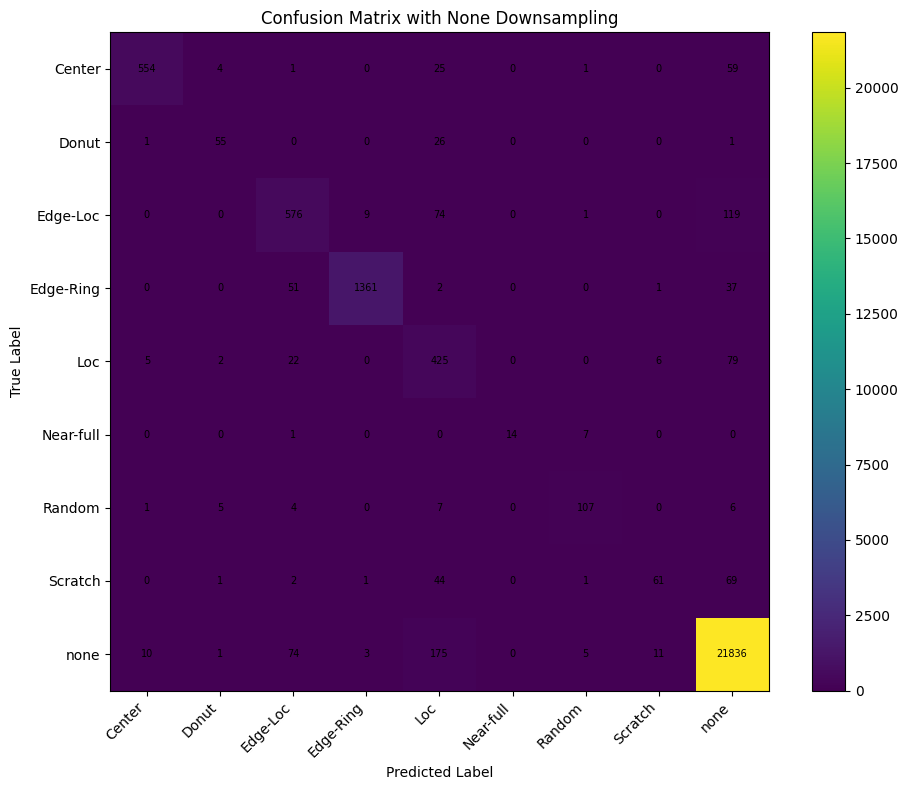

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/figures/confusion_matrix_none_downsampling.png


In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(cm_ds)
plt.title("Confusion Matrix with None Downsampling")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(classes)), classes, rotation=45, ha="right")
plt.yticks(np.arange(len(classes)), classes)
plt.colorbar()

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(
            j, i,
            str(cm_ds[i, j]),
            ha="center",
            va="center",
            fontsize=7
        )

plt.tight_layout()
plt.savefig(CM_SAVE_PATH_DS, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", CM_SAVE_PATH_DS)

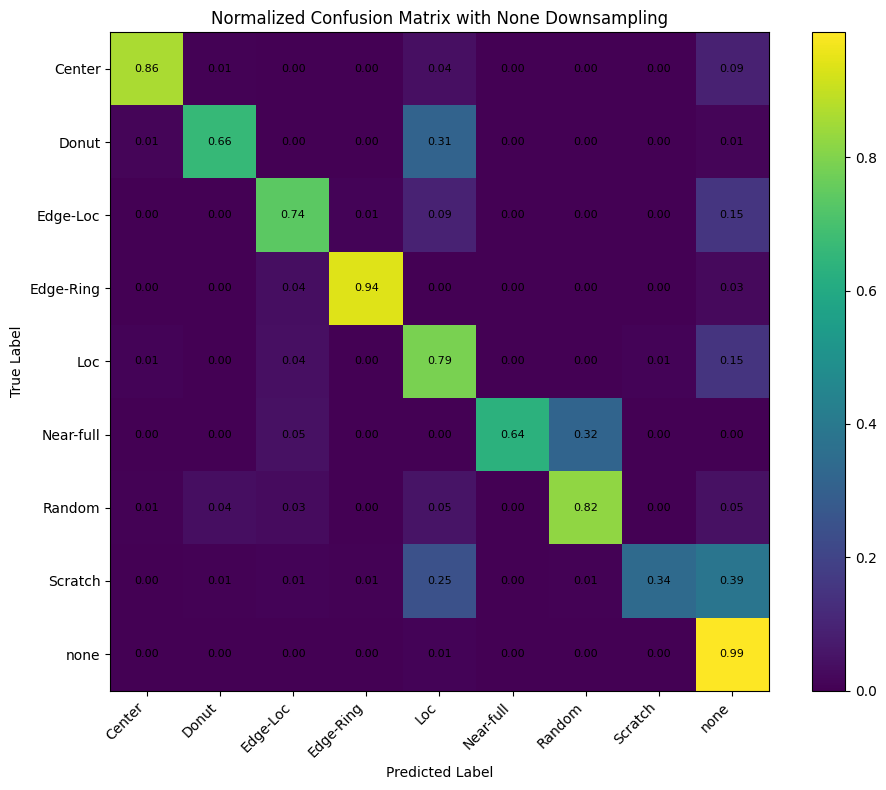

Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/figures/normalized_confusion_matrix_none_downsampling.png


In [56]:
cm_norm_ds = cm_ds.astype("float") / cm_ds.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
plt.imshow(cm_norm_ds)
plt.title("Normalized Confusion Matrix with None Downsampling")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(classes)), classes, rotation=45, ha="right")
plt.yticks(np.arange(len(classes)), classes)
plt.colorbar()

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(
            j, i,
            f"{cm_norm_ds[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.savefig(NORM_CM_SAVE_PATH_DS, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", NORM_CM_SAVE_PATH_DS)

In [57]:
error_df_ds = pd.DataFrame({
    "true": y_test,
    "pred": y_pred_ds
})

error_df_ds = error_df_ds[
    error_df_ds["true"] != error_df_ds["pred"]
].copy()

error_df_ds["true_label"] = error_df_ds["true"].apply(lambda x: classes[x])
error_df_ds["pred_label"] = error_df_ds["pred"].apply(lambda x: classes[x])

top_errors_ds = (
    error_df_ds
    .groupby(["true_label", "pred_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(top_errors_ds.head(20))

top_errors_ds.head(20).to_csv(
    TOP_ERROR_SAVE_PATH_DS,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", TOP_ERROR_SAVE_PATH_DS)

,true_label,pred_label,count
38,none,Loc,175
11,Edge-Loc,none,119
20,Loc,none,79
9,Edge-Loc,Loc,74
36,none,Edge-Loc,74
33,Scratch,none,69
4,Center,none,59
12,Edge-Ring,Edge-Loc,51
31,Scratch,Loc,44
15,Edge-Ring,none,37


Saved: /content/drive/MyDrive/wafer-map-defect-xai/outputs/reports/misclassification_top20_none_downsampling.csv


In [58]:
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

acc_ds = accuracy_score(y_test, y_pred_ds)
macro_f1_ds = f1_score(y_test, y_pred_ds, average="macro")
weighted_f1_ds = f1_score(y_test, y_pred_ds, average="weighted")

precision_ds, recall_ds, f1_ds, support_ds = precision_recall_fscore_support(
    y_test,
    y_pred_ds,
    labels=np.arange(len(classes))
)

summary_ds = pd.DataFrame({
    "class": classes,
    "precision": precision_ds,
    "recall": recall_ds,
    "f1": f1_ds,
    "support": support_ds
})

display(summary_ds)

print("Accuracy with none downsampling:", acc_ds)
print("Macro F1 with none downsampling:", macro_f1_ds)
print("Weighted F1 with none downsampling:", weighted_f1_ds)

,class,precision,recall,f1,support
0,Center,0.970228,0.860248,0.911934,644
1,Donut,0.808824,0.662651,0.728477,83
2,Edge-Loc,0.787962,0.739409,0.762914,779
3,Edge-Ring,0.990539,0.937328,0.963199,1452
4,Loc,0.546272,0.788497,0.645406,539
5,Near-full,1.000000,0.636364,0.777778,22
6,Random,0.877049,0.823077,0.849206,130
7,Scratch,0.772152,0.340782,0.472868,179
8,none,0.983338,0.987384,0.985357,22115


Accuracy with none downsampling: 0.9632270747407778
Macro F1 with none downsampling: 0.7885710168238357
Weighted F1 with none downsampling: 0.963335598431195
